# Implementación de la propagación hacia adelante en una red neuronal simple

## 1. Introducción

En este cuaderno implementarás la propagación hacia adelante (forward propagation) en una red neuronal totalmente conectada.

Antes de entrar en el código, repasemos brevemente algunos conceptos y definiciones clave. Estos se resumen en la siguiente tabla.

### 1.1 Conceptos clave

| **Concepto**                | **Descripción** |
|---------------------------|-----------------|
| **Red Neuronal (NN)**   | Un modelo computacional compuesto por capas de nodos (neuronas) interconectados que transforman los datos de entrada para aprender patrones. |
| **Red Totalmente Conectada (FCN)** | Un tipo de red neuronal en la que cada neurona de una capa está conectada con todas las neuronas de la siguiente capa. Es la arquitectura más simple usada para aproximación de funciones, clasificación y tareas de regresión. |
| **Capa**                 | Un conjunto de neuronas que procesa los datos de entrada. Las capas pueden ser de entrada, ocultas o de salida. |
| **Neurona (Unidad)**         | Una unidad básica de cómputo en una red. Cada neurona realiza una suma ponderada de sus entradas seguida de una función de activación. |
| **Matriz de Pesos ($\mathbf{W}$)** | Una matriz que almacena los parámetros entrenables entre capas. Cada elemento representa la intensidad de la conexión entre dos neuronas. |
| **Vector de Sesgo ($\mathbf{b}$)**   | Un vector que se suma a la suma ponderada para dar flexibilidad y mejorar el aprendizaje. Cada capa suele tener su propio vector de sesgo. |
| **Propagación hacia adelante (Forward Propagation)**   | El proceso de calcular las salidas a partir de las entradas, pasando los datos por las capas de la red mediante pesos, sesgos y funciones de activación. |
| **Transformación Lineal** | La operación $ \mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b} $, usada para combinar las entradas mediante parámetros entrenables. |
| **Función de Activación**   | Una función no lineal aplicada a la salida lineal de una neurona, que permite a la red aprender patrones complejos. |
| **ReLU (Unidad Lineal Rectificada)** | Una función de activación definida como $$ \text{ReLU}(z) = \max(0, z) $$ que introduce no linealidad manteniendo la eficiencia computacional. |
| **Función Softmax**      | Convierte un vector de puntuaciones en una distribución de probabilidad:  $$ \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}} $$ Se usa en la capa de salida para clasificación. |
| **Capa Oculta**          | Una capa intermedia entre la entrada y la salida. Las capas ocultas permiten a la red aprender representaciones internas. |
| **Capa de Salida**          | La capa final que produce las predicciones. En tareas de clasificación, suele aplicar softmax para obtener probabilidades de clase. |
| **Clase Predicha ($\hat{y}$)** | La clase con la probabilidad predicha más alta: $$ \hat{y} = \arg\max_i \mathbf{a}^{[2]}_i $$ |
| **Dimensionalidad**        | Se refiere al número de características o unidades en cada capa. Las dimensiones deben coincidir para que las operaciones matriciales sean válidas. |
| **Multiplicación de Matrices** | La operación central de la propagación hacia adelante, denotada $ \mathbf{W}\mathbf{x} $. Garantiza la combinación lineal de las entradas. |
| **Vectorización**         | Expresar cálculos usando operaciones matriciales y vectoriales para mejorar la eficiencia y la legibilidad del código. |
| **Procesamiento por Lotes (Batch Processing)**      | Alimentar varias entradas a la vez (como una matriz de entradas) para aprovechar el paralelismo durante las pasadas hacia adelante. |

### 1.2 Arquitectura de una red totalmente conectada (FCN)

En este ejercicio implementaremos una **red totalmente conectada (FCN)**, también conocida como red neuronal feedforward. Este tipo de red consiste en capas donde cada neurona de una capa está conectada con todas las neuronas de la siguiente capa.

La arquitectura de una FCN está definida por los siguientes componentes:

- **Dimensión de entrada**: el número de características en el vector de entrada.
- **Número de capas ocultas**: capas intermedias entre la entrada y la salida, responsables de aprender representaciones internas.
- **Neuronas por capa oculta**: el número de unidades en cada capa oculta.
- **Funciones de activación**: transformaciones no lineales aplicadas después de cada capa para que la red pueda aprender patrones complejos.
- **Dimensión de salida**: el número de clases (para clasificación) o valores de salida (para regresión).

El siguiente código genera una FCN con una dimensión de entrada de 2, una capa oculta con tres neuronas, y una dimensión de salida de 2.

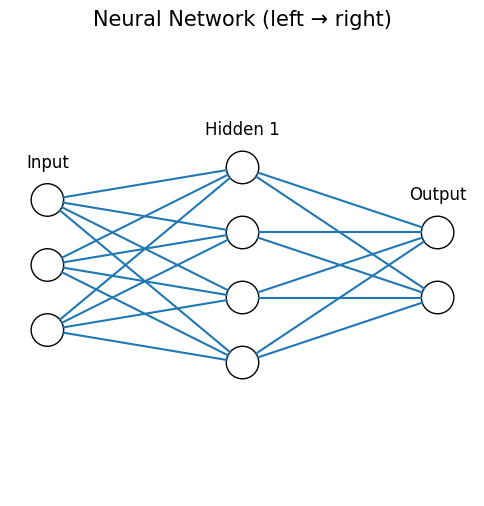

In [2]:
from utils import NeuralNetwork

nn_dim = [3, 4, 2]
nn = NeuralNetwork(nn_dim)
nn.draw()

Intenta cambiar la arquitectura modificando la variable nn_dim. Crea una red con una dimensión de entrada de 3, dos capas ocultas con 5 neuronas cada una, y una dimensión de salida de 2. Luego, dibuja la arquitectura resultante.

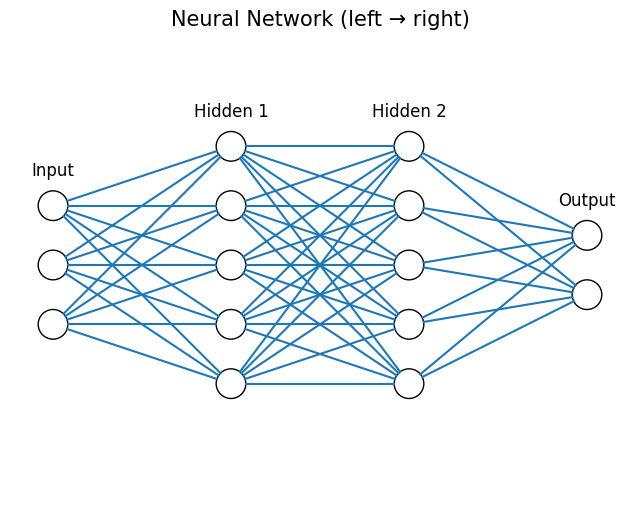

✅ Architecture matches the expected configuration!


In [3]:
# TODO: Cambia la arquitectura modificando la variable nn_dim.

from exercise_validator import validate_nn_architecture

nn_dim = [3, 5, 5, 2]
nn = NeuralNetwork(nn_dim)
nn.draw()

# Validar la solución
is_valid, message = validate_nn_architecture(nn_dim)
print(message)

### 1.2 Propagación hacia adelante en una FCN

La propagación hacia adelante es el proceso de pasar la entrada por la red, capa por capa, aplicando transformaciones lineales seguidas de funciones de activación, hasta producir la salida final.

Formalmente, para una red totalmente conectada con una capa oculta, los cálculos proceden de la siguiente manera:

- Sea el vector de entrada $\mathbf{x} \in \mathbb{R}^{n_0}$
- Sean la matriz de pesos y el vector de sesgo de la capa 1:
  - $\mathbf{W}^{[1]} \in \mathbb{R}^{n_1 \times n_0}$
  - $\mathbf{b}^{[1]} \in \mathbb{R}^{n_1}$
- Sean la matriz de pesos y el vector de sesgo de la capa de salida:
  - $\mathbf{W}^{[2]} \in \mathbb{R}^{n_2 \times n_1}$
  - $\mathbf{b}^{[2]} \in \mathbb{R}^{n_2}$

Los pasos de la propagación hacia adelante son:

1. **Transformación lineal de la primera capa**
   $$
   \mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]}, \quad \mathbf{z}^{[1]} \in \mathbb{R}^{n_1}
   $$

2. **Activación de la primera capa (p. ej., ReLU)**
   $$
   \mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]}), \quad \mathbf{a}^{[1]} \in \mathbb{R}^{n_1}
   $$

3. **Transformación lineal de la capa de salida**
   $$
   \mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]}, \quad \mathbf{z}^{[2]} \in \mathbb{R}^{n_2}
   $$

4. **Activación de salida (p. ej., softmax para clasificación)**
   $$
   \mathbf{a}^{[2]} = \text{softmax}(\mathbf{z}^{[2]}), \quad \mathbf{a}^{[2]} \in \mathbb{R}^{n_2}
   $$

---

**Ejemplo:**
Consideremos una FCN con:

- Dimensión de entrada: $n_0 = 3$
- Tamaño de la capa oculta: $n_1 = 4$
- Dimensión de salida: $n_2 = 2$

Las dimensiones correspondientes de los parámetros y cálculos intermedios serán:

- $\mathbf{x} \in \mathbb{R}^{3}$
- $\mathbf{W}^{[1]} \in \mathbb{R}^{4 \times 3}$, $\mathbf{b}^{[1]} \in \mathbb{R}^{4}$
- $\mathbf{z}^{[1]}, \mathbf{a}^{[1]} \in \mathbb{R}^{4}$
- $\mathbf{W}^{[2]} \in \mathbb{R}^{2 \times 4}$, $\mathbf{b}^{[2]} \in \mathbb{R}^{2}$
- $\mathbf{z}^{[2]}, \mathbf{a}^{[2]} \in \mathbb{R}^{2}$

Esta configuración produce un vector de salida de 2 dimensiones que puede interpretarse como probabilidades de clase en una tarea de clasificación binaria.

Asignemos los siguientes valores:

**Vector de entrada:**
$$
\mathbf{x} =
\begin{bmatrix}
1.0 \\
2.0 \\
-1.0
\end{bmatrix}
$$

**Pesos y sesgos de la capa oculta:**
$$
\mathbf{W}^{[1]} =
\begin{bmatrix}
0.2 & -0.4 & 0.1 \\
0.7 & 0.3 & -0.2 \\
-0.5 & 0.6 & 0.4 \\
0.1 & -0.1 & 0.2
\end{bmatrix},
\quad
\mathbf{b}^{[1]} =
\begin{bmatrix}
0.0 \\
0.1 \\
-0.2 \\
0.05
\end{bmatrix}
$$

Calculemos la primera transformación lineal usando **numpy**:

In [4]:
import numpy as np

x = np.array([1.0, 2.0, -1.0])
W1 = np.array([[0.2, -0.4, 0.1], [0.7, 0.3, -0.2], [-0.5, 0.6, 0.4], [0.1, -0.1, 0.2]])
b1 = np.array([0.0, 0.1, -0.2, 0.05])
z1 = np.dot(W1, x) + b1
print(z1)

[-0.7   1.6   0.1  -0.25]


En notación matricial tenemos

$$
\mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]} =
\begin{bmatrix}
(0.2)(1.0) + (-0.4)(2.0) + (0.1)(-1.0) \\
(0.7)(1.0) + (0.3)(2.0) + (-0.2)(-1.0) \\
(-0.5)(1.0) + (0.6)(2.0) + (0.4)(-1.0) \\
(0.1)(1.0) + (-0.1)(2.0) + (0.2)(-1.0)
\end{bmatrix}
+
\begin{bmatrix}
0.0 \\
0.1 \\
-0.2 \\
0.05
\end{bmatrix}
=
\begin{bmatrix}
-0.7 \\
1.6 \\
0.1 \\
-0.25
\end{bmatrix}
$$

Aplica la activación ReLU:

In [5]:
a1 = np.maximum(0, z1)
print(a1)

[0.  1.6 0.1 0. ]


$$
\mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]}) =
\begin{bmatrix}
0.0 \\
1.6 \\
0.1 \\
0.0
\end{bmatrix}
$$

**Pesos y sesgos de la capa de salida:**
$$
\mathbf{W}^{[2]} =
\begin{bmatrix}
0.5 & -0.3 & 0.8 & -0.1 \\
-0.4 & 0.6 & 0.1 & 0.2
\end{bmatrix},
\quad
\mathbf{b}^{[2]} =
\begin{bmatrix}
0.0 \\
0.05
\end{bmatrix}
$$

Calculemos la transformación de la capa de salida usando **numpy**:

In [6]:
W2 = np.array([[0.5, -0.3, 0.8, -0.1], [-0.4, 0.6, 0.1, 0.2]])
b2 = np.array([0.0, 0.05])
z2 = np.dot(W2, a1) + b2
print(z2)

[-0.4   1.02]


En notación matricial tenemos

$$
\mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]} =
\begin{bmatrix}
(0.5)(0.0) + (-0.3)(1.6) + (0.8)(0.1) + (-0.1)(0.0) \\
(-0.4)(0.0) + (0.6)(1.6) + (0.1)(0.1) + (0.2)(0.0)
\end{bmatrix}
+
\begin{bmatrix}
0.0 \\
0.05
\end{bmatrix}
=
\begin{bmatrix}
-0.4 \\
1.02
\end{bmatrix}
$$

Aplica la función softmax:

In [7]:
a2 = np.exp(z2) / np.sum(np.exp(z2))
print(a2)

[0.19466158 0.80533842]


$$
\mathbf{a}^{[2]} = \text{softmax}(\mathbf{z}^{[2]}) =
\frac{1}{e^{-0.4} + e^{1.02}} \cdot
\begin{bmatrix}
e^{-0.4} \\
e^{1.02}
\end{bmatrix}
\approx
\begin{bmatrix}
0.195 \\
0.805
\end{bmatrix}
$$

## 2. Implementa tu propia red totalmente conectada (FCN)

En esta sección implementarás una **red totalmente conectada (FCN)** simple usando una estructura basada en clases en Python. La arquitectura de la red es la siguiente:

1. **Capa de Entrada**: 2 unidades, que reciben un vector de características $\mathbf{x} \in \mathbb{R}^2$
2. **Capa Oculta**: 2 unidades con activación ReLU
   - Transformación lineal: $\mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]}$
   - Activación: $\mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]})$
3. **Capa de Salida**: 2 unidades con activación softmax
   - Transformación lineal: $\mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]}$
   - Activación: $\mathbf{y} = \text{softmax}(\mathbf{z}^{[2]})$

---

### ✍️ Tarea

Tu tarea es completar la clase `SimpleFCN` rellenando los componentes faltantes. La clase tendrá dos responsabilidades principales:

---

#### 1. **Asignar los parámetros de la red**

Asigna manualmente los valores de los pesos y sesgos de la red usando lo siguiente:

- $\mathbf{W}^{[1]} \in \mathbb{R}^{2 \times 2}, \quad \mathbf{b}^{[1]} \in \mathbb{R}^{2}$
- $\mathbf{W}^{[2]} \in \mathbb{R}^{2 \times 2}, \quad \mathbf{b}^{[2]} \in \mathbb{R}^{2}$

**Usa estos valores fijos:**

$$
\mathbf{W}^{[1]} =
\begin{bmatrix}
0.2 & -0.4 \\
0.7 & 0.3
\end{bmatrix}, \quad
\mathbf{b}^{[1]} =
\begin{bmatrix}
0.1 \\
0.0
\end{bmatrix}
$$

$$
\mathbf{W}^{[2]} =
\begin{bmatrix}
0.5 & -0.3 \\
-0.4 & 0.6
\end{bmatrix}, \quad
\mathbf{b}^{[2]} =
\begin{bmatrix}
0.0 \\
0.05
\end{bmatrix}
$$

---

#### 2. **Realizar la propagación hacia adelante**

Implementarás la pasada completa hacia adelante desde la entrada $\mathbf{x}$ hasta la salida $\mathbf{y}$ combinando los siguientes componentes:

- Una **función de transformación lineal**
- Una **función de activación ReLU**
- Una **función softmax**
- Un método `forward()` que encadena todos los pasos

---

### 🧩 Componentes a implementar

1. **Inicialización de parámetros**
   Usa los valores proporcionados para los pesos y sesgos de ambas capas.

2. **Forward Lineal**
   Implementa la transformación afín:
   $$
   \mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}
   $$

3. **Activación ReLU**
   Aplica la función ReLU elemento a elemento:
   $$
   \text{ReLU}(z_i) = \max(0, z_i)
   $$

4. **Activación Softmax**
   Convierte las puntuaciones sin procesar en probabilidades:
   $$
   \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}
   $$

5. **Pasada hacia adelante (Forward Pass)**
   Combina todos los componentes para calcular la salida de la red:
   $$
   \mathbf{y} = \text{softmax} \left( \mathbf{W}^{[2]} \cdot \text{ReLU}\left( \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]} \right) + \mathbf{b}^{[2]} \right)
   $$

In [ ]:
# TODO: Completa la implementación de la clase SimpleFCN rellenando los métodos faltantes

import numpy as np

class SimpleFCN:
    def __init__(self):
        # Asigna los pesos y sesgos fijos de la capa 1
        self.W1 = None # TODO: Asigna los pesos de la capa 1
        self.b1 = None # TODO: Asigna los sesgos de la capa 1

        # Asigna los pesos y sesgos fijos de la capa 2
        self.W2 = None # TODO: Asigna los pesos de la capa 2
        self.b2 = None # TODO: Asigna los sesgos de la capa 2

    def relu(self, z):
        """
        Aplica la función ReLU elemento a elemento:
        ReLU(z_i) = max(0, z_i)
        """
        pass # TODO: Implementa la función ReLU

    def softmax(self, z):
        """
        Convierte las puntuaciones sin procesar en probabilidades:
        z_hat = z - max(z) # truco de estabilidad numérica
        softmax(z_hat_i) = exp(z_hat_i) / sum(exp(z_hat_j))
        """
        pass # TODO: Implementa la función softmax

    def linear_forward(self, W, x, b):
        """
        Implementa la propagación lineal hacia adelante: z = Wx + b
        Args:
            x: vector de entrada (n,)
            W: matriz de pesos (m,n)
            b: vector de sesgo (m,)
        Returns:
            z: vector de salida (m,)
        """
        pass # TODO: Implementa la función de transformación lineal

    def forward(self, x):
        # Primera capa
        z1 = None # TODO: Transformación lineal de la primera capa
        a1 = None # TODO: Activación ReLU de la primera capa

        # Capa de salida
        z2 = None # TODO: Transformación lineal de la capa de salida
        y = None # TODO: Activación softmax de la capa de salida
        return y

# Crea la red
model = SimpleFCN()

# Define el vector de entrada
x = np.array([1.0, 2.0])

# Ejecuta la pasada hacia adelante
output = model.forward(x)
print("Probabilidades de salida:", output)

### Prueba tu implementación

Si tu implementación es correcta, podrás ejecutar esta celda exitosamente:

In [ ]:
from exercise_validator import test_linear_forward, test_relu, test_softmax, test_forward

# Ejecutar todas las pruebas
print("🏁 Ejecutando todas las pruebas unitarias...\n")
test_linear_forward(model)
test_relu(model)
test_softmax(model)
test_forward(model)
print("\n🎉 ¡Todas las pruebas se completaron!")

## 3. Bonus: Extender la FCN para manejar lotes (batches)

En esta tarea adicional, extenderás tu clase `SimpleFCN` para soportar **entradas por lotes (batch inputs)**.

Actualmente, la red está diseñada para aceptar un único vector de entrada $\mathbf{x} \in \mathbb{R}^n$. Sin embargo, en aplicaciones prácticas, a menudo procesamos varias entradas a la vez. Un lote de entradas puede representarse como una matriz $\mathbf{X} \in \mathbb{R}^{\text{batch\_size} \times n}$, donde cada fila corresponde a un ejemplo de entrada distinto.

### 👩‍💻 Tu tarea:

- Crea una nueva clase `BatchedFCN` que herede de `SimpleFCN`.
- Reimplementa el método `linear_forward()` para soportar entradas matriciales.
- Modifica el método `forward()` para manejar un lote de entradas.
- Asegúrate de que todas las operaciones —transformaciones lineales, activaciones y softmax— funcionen correctamente a lo largo de la dimensión del lote.

> 💡 Dependiendo de cómo hayas implementado el método `linear_forward` en `SimpleFCN`, tu código ya podría generalizarse a entradas por lotes. Sin embargo, por claridad y estructura, se te anima a adaptarlo y probarlo explícitamente en este contexto.

Puedes asumir que la entrada es un arreglo de NumPy de forma `(batch_size, input_dim)`, y la salida debe tener forma `(batch_size, output_dim)`.


In [ ]:
import numpy as np

class BatchedFCN(SimpleFCN):
    def linear_forward(self, W, X, b):
        """
        Calcula la transformación lineal Z = XWᵀ + b para un lote de entradas.
        Parameters:
            W: matriz de pesos de forma (output_dim, input_dim)
            X: matriz de entrada de forma (batch_size, input_dim)
            b: vector de sesgo de forma (output_dim,)
        Returns:
            Z: matriz de salida de forma (batch_size, output_dim)
        """
        # TODO: Implementa la transformación lineal por lotes
        Z = None # tu código aquí
        return Z

    def forward(self, X_batch):
        """
        Pasada hacia adelante para un lote de entradas.
        Parameters:
            X_batch: forma (batch_size, input_dim)
        Returns:
            Y: probabilidades de salida para cada entrada del lote,
               forma (batch_size, output_dim)
        """
        # TODO: Reutiliza linear_forward, ReLU y softmax para un lote
        z1 = None # tu código aquí
        a1 = None # tu código aquí
        z2 = None # tu código aquí
        Y = None # tu código aquí
        return Y

### Prueba tu implementación

Si tu implementación es correcta, podrás ejecutar esta celda exitosamente:

In [ ]:
from exercise_validator import test_batched_forward

model = BatchedFCN()
test_batched_forward(model)